In [1]:
# Install if not already installed
!pip install tensorflow numpy pandas matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [3]:
# Load only top 10,000 most frequent words
vocab_size = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 25000
Testing samples: 25000


In [4]:
max_len = 200

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

print("Shape after padding:", x_train.shape)

Shape after padding: (25000, 200)


In [5]:
model = Sequential()

# Embedding Layer
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))

# LSTM Layer
model.add(LSTM(128, return_sequences=False))

# Dropout (avoid overfitting)
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

# Compile
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

C:\Users\anura\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 122s 365ms/step - accuracy: 0.7748 - loss: 0.4643 - val_accuracy: 0.8656 - val_loss: 0.3271
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 112s 359ms/step - accuracy: 0.8934 - loss: 0.2662 - val_accuracy: 0.8600 - val_loss: 0.3336
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 111s 353ms/step - accuracy: 0.9241 - loss: 0.2016 - val_accuracy: 0.8462 - val_loss: 0.4441
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 113s 360ms/step - accuracy: 0.9463 - loss: 0.1508 - val_accuracy: 0.8630 - val_loss: 0.3945
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 148s 381ms/step - accuracy: 0.9586 - loss: 0.1176 - val_accuracy: 0.8174 - val_loss: 0.4272


In [7]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 86ms/step - accuracy: 0.8227 - loss: 0.4242
Test Accuracy: 0.8227199912071228


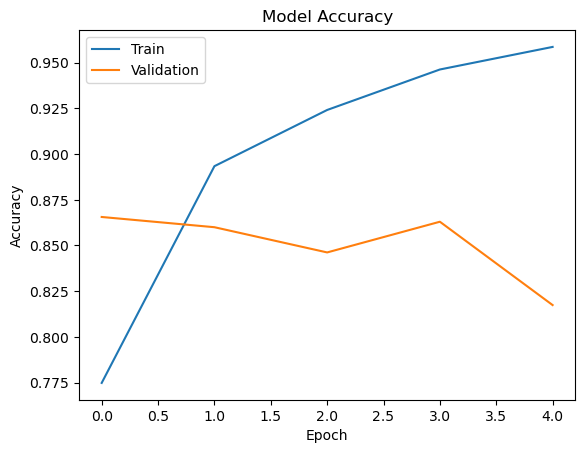

In [8]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [9]:
sample = x_test[0].reshape(1, -1)
prediction = model.predict(sample)

if prediction > 0.5:
    print("Positive Review 😊")
else:
    print("Negative Review 😡")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 729ms/step
Negative Review 😡


In [10]:
word_index = imdb.get_word_index()

reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

print(decode_review(x_train[0]))

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you think the whole story was so lovely because it was true and was someone'